# Commodity Price and News Sentiment Pipeline

This notebook organizes the full workflow into a clear sequence:

1. **Load and inspect the news and price datasets**
2. **Clean and standardize the input columns**
3. **Score headlines with FinBERT sentiment**
4. **Classify commodity topics using sentence embeddings**
5. **Aggregate daily sentiment signals**
6. **Merge sentiment features with commodity prices**
7. **Analyze correlation with clearer plots and lag features**


## 0. Imports and notebook options

This section loads the libraries used for data handling, sentiment modeling, topic classification, and visualization.


In [1]:

# =========================
# Imports
# =========================
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm
tqdm.pandas()

pd.set_option("display.max_colwidth", 160)


## 1. Configuration

These settings control file paths, runtime trade-offs, and topic labels.

- `USE_SAMPLE=True` keeps the notebook fast while you test the pipeline.
- Set `USE_SAMPLE=False` when you want to analyze the full dataset.
- The embedding threshold avoids forcing weak matches into a topic.


In [2]:

# =========================
# Configuration
# =========================
base = Path.cwd()
if base.name == "codes":
    base = base.parent

NEWS_JSONL_PATH = base / "data" / "_checkbt_energy_commodities_2y_playwright.jsonl"
OIL_JSON_PATH = base / "data" / "brent_daily_20260228_075143.json"

NEWS_CSV_PATH = base / "data" / "processed" / "news.csv"
OIL_CSV_PATH = base / "data" / "processed" / "oil_price.csv"

USE_SAMPLE = True
SAMPLE_SIZE = 500
RANDOM_STATE = 42

TOPIC_THRESHOLD = 0.30
TARGET_TOPIC = "oil"

TOPIC_DESCRIPTIONS = {
    "oil": "crude oil petroleum brent wti refinery diesel gasoline fuel market upstream downstream energy supply",
    "gas": "natural gas lng natgas pipeline gas supply energy market utility",
    "gold": "gold bullion precious metals inflation hedge safe haven commodity market",
    "energy": "energy market electricity power renewable opec production supply demand utilities"
}


## 2. Helper functions

These helper functions keep the notebook tidy and make each transformation easier to understand and reuse.


In [6]:

def load_json_or_jsonl(path: Path):
    """Load a JSON or JSONL file and return the parsed Python object.

    Parameters
    ----------
    path : Path
        Path to a JSON or JSONL file.

    Returns
    -------
    object
        Parsed content. For JSONL files, this will usually be a list of records.
    """
    text = path.read_text(encoding="utf-8").strip()
    if text.startswith("[") or text.startswith("{"):
        return json.loads(text)
    with path.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def prepare_news_dataframe(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Standardize the raw news dataframe for downstream processing.

    Expected source columns:
    - title
    - published_at

    Optional columns that may also exist:
    - summary
    - url
    - section

    The returned dataframe contains:
    - headline
    - date
    - summary
    - url
    - section

    Parameters
    ----------
    df_raw : pd.DataFrame
        Raw news dataframe loaded from CSV.

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe with standardized column names and parsed dates.
    """
    df = df_raw.rename(columns={"title": "headline", "published_at": "date"}).copy()

    # Keep useful columns if they exist
    wanted_cols = ["headline", "date", "summary", "url", "section"]
    existing_cols = [col for col in wanted_cols if col in df.columns]
    df = df[existing_cols].dropna(subset=["headline", "date"])

    df["headline"] = df["headline"].astype(str).str.strip()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

    # Optional cleanup for weird text encoding like â€™
    for col in ["headline", "summary"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("â€™", "'", regex=False)
                .str.replace("â€œ", '"', regex=False)
                .str.replace("â€\x9d", '"', regex=False)
                .str.replace("â€“", "-", regex=False)
            )

    df = df.dropna(subset=["date"])
    df = df[df["headline"] != ""].reset_index(drop=True)
    return df

import ast

def prepare_price_dataframe(price_raw: pd.DataFrame) -> pd.DataFrame:
    """Standardize the commodity price dataframe.

    This version is designed for CSVs where the actual date and price are stored
    inside a stringified dictionary in the `data` column, for example:

        {'date': '2026-02-23', 'value': '71.9'}

    The returned dataframe contains:
    - date
    - price

    Parameters
    ----------
    price_raw : pd.DataFrame
        Raw price dataframe loaded from CSV.

    Returns
    -------
    pd.DataFrame
        Cleaned price dataframe with parsed `date` and numeric `price`.
    """
    price_df = price_raw.copy()

    if "data" not in price_df.columns:
        raise KeyError("Expected a 'data' column in the price CSV.")

    def parse_data_cell(cell):
        """Parse one row of the stringified dictionary in the `data` column."""
        if pd.isna(cell):
            return {}
        if isinstance(cell, dict):
            return cell
        try:
            return ast.literal_eval(str(cell))
        except (ValueError, SyntaxError):
            return {}

    parsed = price_df["data"].apply(parse_data_cell)

    price_df["date"] = parsed.apply(lambda x: x.get("date"))
    price_df["price"] = parsed.apply(lambda x: x.get("value"))

    price_df["date"] = pd.to_datetime(price_df["date"], errors="coerce").dt.date
    price_df["price"] = pd.to_numeric(price_df["price"], errors="coerce")

    price_df = price_df.dropna(subset=["date", "price"])
    price_df = price_df[["date", "price"]].sort_values("date").reset_index(drop=True)

    return price_df


def get_sentiment(text: str, tokenizer, model, device) -> float:
    """Compute a FinBERT sentiment score for one headline.

    The score uses:
        (positive - negative) * (1 - neutral)

    This keeps the sign of the sentiment while reducing the effect of very neutral headlines.

    Parameters
    ----------
    text : str
        Headline text.
    tokenizer : transformers tokenizer
        Tokenizer for FinBERT.
    model : transformers model
        FinBERT sequence classification model.
    device : torch.device
        CPU or GPU device.

    Returns
    -------
    float
        Sentiment score for the headline.
    """
    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    positive, negative, neutral = probs
    score = (positive - negative) * (1 - neutral)
    return float(score)


def classify_topics_with_embeddings(
    headlines: pd.Series,
    topic_descriptions: dict,
    embed_model: SentenceTransformer,
    threshold: float = 0.30,
):
    """Classify headlines into topics using sentence embeddings.

    Each topic is represented by a short semantic description.
    Headlines are encoded in batch, compared against topic embeddings, and
    assigned to the most similar topic if the similarity exceeds `threshold`.

    Parameters
    ----------
    headlines : pd.Series
        Series of headline strings.
    topic_descriptions : dict
        Mapping of topic name -> descriptive text.
    embed_model : SentenceTransformer
        Sentence-transformers embedding model.
    threshold : float, default=0.30
        Minimum cosine similarity required to keep a topic assignment.

    Returns
    -------
    tuple[pd.Series, pd.Series, pd.DataFrame]
        topic labels, best similarity scores, and the full similarity matrix.
    """
    topic_names = list(topic_descriptions.keys())
    topic_texts = list(topic_descriptions.values())

    topic_vectors = embed_model.encode(topic_texts, convert_to_numpy=True)
    headline_vectors = embed_model.encode(
        headlines.astype(str).tolist(),
        convert_to_numpy=True,
        show_progress_bar=True
    )

    sim_matrix = cosine_similarity(headline_vectors, topic_vectors)

    best_idx = np.argmax(sim_matrix, axis=1)
    best_scores = np.max(sim_matrix, axis=1)
    labels = np.array([topic_names[i] for i in best_idx], dtype=object)
    labels[best_scores < threshold] = "other"

    similarity_df = pd.DataFrame(sim_matrix, columns=[f"sim_{t}" for t in topic_names])
    return pd.Series(labels, index=headlines.index), pd.Series(best_scores, index=headlines.index), similarity_df


def aggregate_daily_signals(topic_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate daily news sentiment into richer summary signals.

    The aggregated features include:
    - average sentiment
    - median sentiment
    - sentiment spread (standard deviation)
    - number of headlines
    - a volume-adjusted sentiment score

    Parameters
    ----------
    topic_df : pd.DataFrame
        News dataframe filtered to one topic. Must contain `date`, `headline`, and `sentiment`.

    Returns
    -------
    pd.DataFrame
        Daily aggregated sentiment features.
    """
    daily = (
        topic_df.groupby("date")
        .agg(
            avg_sentiment=("sentiment", "mean"),
            median_sentiment=("sentiment", "median"),
            sentiment_std=("sentiment", "std"),
            max_sentiment=("sentiment", "max"),
            min_sentiment=("sentiment", "min"),
            news_volume=("headline", "count"),
        )
        .reset_index()
        .sort_values("date")
        .reset_index(drop=True)
    )

    daily["sentiment_std"] = daily["sentiment_std"].fillna(0.0)
    daily["sentiment_volume_weighted"] = daily["avg_sentiment"] * np.log1p(daily["news_volume"])
    return daily


def build_analysis_features(merged_df: pd.DataFrame) -> pd.DataFrame:
    """Create lagged and return-based features after merging sentiment with price.

    Parameters
    ----------
    merged_df : pd.DataFrame
        Merged dataframe with at least `date`, `price`, and `avg_sentiment`.

    Returns
    -------
    pd.DataFrame
        Dataframe with additional lag and price-movement features.
    """
    df = merged_df.sort_values("date").reset_index(drop=True).copy()

    df["price_change"] = df["price"].diff()
    df["price_return"] = df["price"].pct_change()

    df["future_price_change"] = df["price"].shift(-1) - df["price"]
    df["future_price_return"] = df["price"].shift(-1) / df["price"] - 1

    for lag in [1, 2, 3, 5, 7]:
        df[f"avg_sentiment_lag{lag}"] = df["avg_sentiment"].shift(lag)
        df[f"news_volume_lag{lag}"] = df["news_volume"].shift(lag)

    return df


def plot_scaled_overlay(df_plot: pd.DataFrame, x_col: str, y_cols: list, title: str):
    """Plot multiple series on the same scale using standardization.

    Parameters
    ----------
    df_plot : pd.DataFrame
        Dataframe containing the columns to plot.
    x_col : str
        Column for the x-axis.
    y_cols : list
        Columns to standardize and plot.
    title : str
        Plot title.
    """
    plot_df = df_plot[[x_col] + y_cols].dropna().copy()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(plot_df[y_cols])

    plt.figure(figsize=(12, 6))
    for i, col in enumerate(y_cols):
        plt.plot(plot_df[x_col], scaled[:, i], label=f"{col} (scaled)")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel("Standardized value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Load the datasets

This section loads the processed CSVs if they exist.  
If they do not exist yet, it builds them from the raw JSON / JSONL files and saves them for reuse.


In [7]:

# =========================
# Load or create datasets
# =========================
if NEWS_CSV_PATH.exists():
    df_raw = pd.read_csv(NEWS_CSV_PATH)
else:
    news_records = load_json_or_jsonl(NEWS_JSONL_PATH)
    df_raw = pd.DataFrame(news_records)
    NEWS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_raw.to_csv(NEWS_CSV_PATH, index=False)

if OIL_CSV_PATH.exists():
    oil_price_raw = pd.read_csv(OIL_CSV_PATH)
else:
    oil_records = load_json_or_jsonl(OIL_JSON_PATH)
    oil_price_raw = pd.DataFrame(oil_records)
    OIL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    oil_price_raw.to_csv(OIL_CSV_PATH, index=False)

print("News raw shape:", df_raw.shape)
print("Price raw shape:", oil_price_raw.shape)
display(df_raw.head())
display(oil_price_raw.head())


News raw shape: (650, 5)
Price raw shape: (517, 4)


,title,summary,url,published_at,section
0,Gold gains as traders mull next Trump moves after tariff ruling,"The dollar falls as much as 0.3%, lifting gold as much as 1.6%",https://www.businesstimes.com.sg/companies-markets/energy-commodities/gold-gains-traders-mull-next-trump-moves-after-tariff-ruling,2026-02-22T09:36:07+00:00,Energy & Commodities
1,China’s Shenzhen cracks down on risky gold trading amid wave of defaults,"[SHENZHEN] Financial regulators in Shenzhen moved to curb illegal gold trading activities, targeting speculative schemes that have contributed to a wave of ...",https://www.businesstimes.com.sg/companies-markets/chinas-shenzhen-cracks-down-risky-gold-trading-amid-wave-defaults,2026-02-21T03:17:05+00:00,Energy & Commodities
2,Trump tariff reversal could cut costs for US energy firms but will likely leave broader flows unchanged,[HOUSTON] The US Supreme Court’s Friday (Feb 20) decision to strike down trade tariffs imposed by President Donald Trump last year may ease costs for some o...,https://www.businesstimes.com.sg/companies-markets/trump-tariff-reversal-could-cut-costs-us-energy-firms-will-likely-leave-broader-flows-unchanged,2026-02-21T02:41:53+00:00,Energy & Commodities
3,"Oil: Brent rises late, settles higher and with weekly gain on Iran-US jitters","[HOUSTON] Brent crude prices rose in late-day short-covering on Friday (Feb 20) as investors worried about US military action, as President Donald Trump pre...",https://www.businesstimes.com.sg/companies-markets/oil-brent-rises-late-settles-higher-and-weekly-gain-iran-us-jitters,2026-02-21T00:42:50+00:00,Energy & Commodities
4,Concord New Energy forecasts over 80% dip in profit for FY2025,This comes on the back of a decline in revenue and gross margin from its power generation business,https://www.businesstimes.com.sg/companies-markets/concord-new-energy-forecasts-over-80-dip-profit-fy2025,2026-02-20T12:51:54+00:00,Energy & Commodities


,name,interval,unit,data
0,Crude Oil Prices Brent,daily,dollars per barrel,"{'date': '2026-02-23', 'value': '71.9'}"
1,Crude Oil Prices Brent,daily,dollars per barrel,"{'date': '2026-02-20', 'value': '72.75'}"
2,Crude Oil Prices Brent,daily,dollars per barrel,"{'date': '2026-02-19', 'value': '73.17'}"
3,Crude Oil Prices Brent,daily,dollars per barrel,"{'date': '2026-02-18', 'value': '71.78'}"
4,Crude Oil Prices Brent,daily,dollars per barrel,"{'date': '2026-02-17', 'value': '69.77'}"


## 4. Clean and standardize the input data

This block makes the downstream pipeline consistent by:
- renaming the news columns to `headline` and `date`
- making sure dates use the same format
- making sure the price dataframe contains a `price` column


In [8]:

df = prepare_news_dataframe(df_raw)
oil_price_df = prepare_price_dataframe(oil_price_raw)

print("Clean news shape:", df.shape)
print("Clean price shape:", oil_price_df.shape)

display(df.head())
display(oil_price_df.head())

print("News date range:", df["date"].min(), "to", df["date"].max())
print("Price date range:", oil_price_df["date"].min(), "to", oil_price_df["date"].max())
print("Price range:", oil_price_df["price"].min(), "to", oil_price_df["price"].max())


Clean news shape: (650, 5)
Clean price shape: (501, 2)


,headline,date,summary,url,section
0,Gold gains as traders mull next Trump moves after tariff ruling,2026-02-22,"The dollar falls as much as 0.3%, lifting gold as much as 1.6%",https://www.businesstimes.com.sg/companies-markets/energy-commodities/gold-gains-traders-mull-next-trump-moves-after-tariff-ruling,Energy & Commodities
1,China’s Shenzhen cracks down on risky gold trading amid wave of defaults,2026-02-21,"[SHENZHEN] Financial regulators in Shenzhen moved to curb illegal gold trading activities, targeting speculative schemes that have contributed to a wave of ...",https://www.businesstimes.com.sg/companies-markets/chinas-shenzhen-cracks-down-risky-gold-trading-amid-wave-defaults,Energy & Commodities
2,Trump tariff reversal could cut costs for US energy firms but will likely leave broader flows unchanged,2026-02-21,[HOUSTON] The US Supreme Court’s Friday (Feb 20) decision to strike down trade tariffs imposed by President Donald Trump last year may ease costs for some o...,https://www.businesstimes.com.sg/companies-markets/trump-tariff-reversal-could-cut-costs-us-energy-firms-will-likely-leave-broader-flows-unchanged,Energy & Commodities
3,"Oil: Brent rises late, settles higher and with weekly gain on Iran-US jitters",2026-02-21,"[HOUSTON] Brent crude prices rose in late-day short-covering on Friday (Feb 20) as investors worried about US military action, as President Donald Trump pre...",https://www.businesstimes.com.sg/companies-markets/oil-brent-rises-late-settles-higher-and-weekly-gain-iran-us-jitters,Energy & Commodities
4,Concord New Energy forecasts over 80% dip in profit for FY2025,2026-02-20,This comes on the back of a decline in revenue and gross margin from its power generation business,https://www.businesstimes.com.sg/companies-markets/concord-new-energy-forecasts-over-80-dip-profit-fy2025,Energy & Commodities


,date,price
0,2024-03-01,84.82
1,2024-03-04,86.58
2,2024-03-05,85.82
3,2024-03-06,86.59
4,2024-03-07,84.88


News date range: 2025-09-21 to 2026-02-22
Price date range: 2024-03-01 to 2026-02-23
Price range: 59.93 to 93.12


## 5. Choose the working dataset

For quick iteration, a sample is useful.  
For time-series analysis, the full dataset is better because random sampling can break the date continuity.

This notebook keeps both options available.


In [9]:

if USE_SAMPLE:
    df_model = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
else:
    df_model = df.sort_values("date").copy()

print("Working dataframe shape:", df_model.shape)
display(df_model.head())


Working dataframe shape: (500, 5)


,headline,date,summary,url,section
637,China’s solar leader looks away from Sun to solve grid glut,2025-09-23,The nationwide plan is to more than double energy storage capacity by 2027,https://www.businesstimes.com.sg/companies-markets/energy-commodities/chinas-solar-leader-looks-away-sun-solve-grid-glut,Energy & Commodities
220,Trump’s Venezuela oil revival plan is a US$100 billion gamble,2026-01-05,The country sits atop the world’s largest oil reserves,https://www.businesstimes.com.sg/international/global/trumps-venezuela-oil-revival-plan-us100-billion-gamble,Energy & Commodities
428,"China suspends ban on exports of gallium, germanium, antimony to US",2025-11-09,"[BEIJING] China has suspended a ban on approving exports of “dual-use items” related to gallium, germanium, antimony and super-hard materials to the US, the...",https://www.businesstimes.com.sg/international/china-suspends-ban-exports-gallium-germanium-antimony-us,Energy & Commodities
326,"Chinese clean-energy foreign investment surging, says think tank",2025-12-09,Washington’s hostility to clean energy has also played into Beijing’s hands,https://www.businesstimes.com.sg/companies-markets/energy-commodities/chinese-clean-energy-foreign-investment-surging-says-think-tank,Energy & Commodities
72,"Oil settles down over 4% on US-Iran de-escalation, easing supply worries",2026-02-02,"[NEW YORK] Oil prices fell more than US$3 per barrel on Monday after US President Donald Trump said Iran was “seriously talking” with Washington, signaling ...",https://www.businesstimes.com.sg/companies-markets/energy-commodities/oil-settles-down-over-4-us-iran-de-escalation-easing-supply-worries,Energy & Commodities


## 6. Load FinBERT

FinBERT is used to score the financial sentiment of each headline.


In [10]:

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    use_safetensors=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("FinBERT loaded on:", device)


FinBERT loaded on: cuda


## 7. Score each headline with FinBERT sentiment

This produces a continuous sentiment score for each headline.
Positive values indicate more positive tone, and negative values indicate more negative tone.


In [11]:

df_model["sentiment"] = df_model["headline"].progress_apply(
    lambda text: get_sentiment(text, tokenizer, model, device)
)

display(df_model[["headline", "sentiment"]].head(10))
df_model["sentiment"].describe()


  0%|          | 0/500 [00:00<?, ?it/s]

,headline,sentiment
637,China’s solar leader looks away from Sun to solve grid glut,0.023804
220,Trump’s Venezuela oil revival plan is a US$100 billion gamble,0.015602
428,"China suspends ban on exports of gallium, germanium, antimony to US",-0.435166
326,"Chinese clean-energy foreign investment surging, says think tank",0.717722
72,"Oil settles down over 4% on US-Iran de-escalation, easing supply worries",-0.848288
516,US-Australia rare earths deal is a start but won’t shake China dominance any time soon,0.084149
181,"China buys at least 10 cargoes of US soybeans for April-May shipment, traders say",0.502038
131,"These Singapore winners can benefit from AI boom, power crunch: Morgan Stanley",0.190082
231,Oil edges higher following biggest annual loss since 2020,0.335124
277,Oil posts second weekly decline as glut concerns dominate,-0.916461


count    500.000000
mean      -0.016002
std        0.585506
min       -0.949701
25%       -0.565801
50%        0.016690
75%        0.484361
max        0.909724
Name: sentiment, dtype: float64

## 8. Classify topics using embeddings

Instead of checking only for exact words such as `"oil"` or `"gold"`, this method compares each headline to a semantic description of each topic.

This is more flexible because a headline can still be recognized as oil-related even if it uses words such as:
- Brent
- WTI
- refinery
- petroleum


In [39]:
# debugging
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()
print(df_model.columns.tolist())
df_model = df_model.loc[:, ~df_model.columns.str.startswith("sim_")].copy()
df_model = df_model.reset_index(drop=True)

['headline', 'date', 'summary', 'url', 'section', 'sentiment', 'topic', 'topic_score', 'sim_oil', 'sim_gas', 'sim_gold', 'sim_energy']


In [40]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_labels, topic_scores, similarity_df = classify_topics_with_embeddings(
    headlines=df_model["headline"],
    topic_descriptions=TOPIC_DESCRIPTIONS,
    embed_model=embed_model,
    threshold=TOPIC_THRESHOLD,
)

df_model["topic"] = topic_labels
df_model["topic_score"] = topic_scores

# Assign similarity columns directly instead of concat
for col in similarity_df.columns:
    df_model[col] = similarity_df[col].values

display(df_model[["headline", "topic", "topic_score"]].head(10))
df_model["topic"].value_counts()

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

,headline,topic,topic_score
0,China’s solar leader looks away from Sun to solve grid glut,other,0.206371
1,Trump’s Venezuela oil revival plan is a US$100 billion gamble,gold,0.329578
2,"China suspends ban on exports of gallium, germanium, antimony to US",other,0.192084
3,"Chinese clean-energy foreign investment surging, says think tank",other,0.297298
4,"Oil settles down over 4% on US-Iran de-escalation, easing supply worries",oil,0.402864
5,US-Australia rare earths deal is a start but won’t shake China dominance any time soon,other,0.253829
6,"China buys at least 10 cargoes of US soybeans for April-May shipment, traders say",other,0.184160
7,"These Singapore winners can benefit from AI boom, power crunch: Morgan Stanley",other,0.133309
8,Oil edges higher following biggest annual loss since 2020,oil,0.327507
9,Oil posts second weekly decline as glut concerns dominate,oil,0.325837


topic
other     332
gold      135
oil       102
energy     42
gas         4
Name: count, dtype: int64

## 9. Inspect a few classification examples

This quick check is useful for debugging whether the embedding classifier is behaving as expected.


In [41]:
display(
    df_model[
        ["headline", "topic", "topic_score", "sim_oil", "sim_gas", "sim_gold", "sim_energy"]
    ].sort_values("topic_score", ascending=False).head(15)
)

,headline,topic,topic_score,sim_oil,sim_gas,sim_gold,sim_energy
301,"Gold slips as profit-taking, softer geopolitical tone hit safe-haven demand",gold,0.668218,0.202300,0.167442,0.668218,0.205289
137,"Gold notches fresh high on safe-haven demand, Fed rate-cut bets",gold,0.623968,0.205225,0.152365,0.623968,0.159750
19,Gold edges down as dollar firms; inflation data in focus,gold,0.620887,0.143158,0.048494,0.620887,0.169429
25,"Gold hovers near record high on safe-haven demand, US rate-cut bets",gold,0.615717,0.105970,0.036297,0.615717,0.108431
39,Gold near record-highs as softer US inflation fuels Fed rate-cut bets,gold,0.590506,0.263328,0.166558,0.590506,0.217110
432,Gold falls as easing geopolitical tensions dampen safe-haven demand,gold,0.587078,0.136143,0.123041,0.587078,0.181099
281,Gold hits record high as US-China trade concerns boost safe-haven demand,gold,0.585154,0.170201,0.144276,0.585154,0.173483
24,Gold hits record high as investors turn to safe haven,gold,0.576558,0.059271,0.044407,0.576558,0.081909
101,"Gold, silver rise to near record highs on lingering safe-haven demand",gold,0.574509,0.083051,0.084710,0.574509,0.149888
311,Gold steady ahead of key US inflation data; silver near record highs,gold,0.560141,0.078689,0.065678,0.560141,0.123822


## 10. Filter the target topic

The notebook focuses on one target commodity at a time.  
Here we filter the working news set to the target topic defined in the configuration block.


In [42]:

topic_df = df_model[df_model["topic"] == TARGET_TOPIC].copy()

print(f"Rows classified as '{TARGET_TOPIC}':", len(topic_df))
display(topic_df[["date", "headline", "sentiment", "topic_score"]].head(10))


Rows classified as 'oil': 102


,date,headline,sentiment,topic_score
4,2026-02-02,"Oil settles down over 4% on US-Iran de-escalation, easing supply worries",-0.848288,0.402864
8,2026-01-02,Oil edges higher following biggest annual loss since 2020,0.335124,0.327507
9,2025-12-19,Oil posts second weekly decline as glut concerns dominate,-0.916461,0.325837
15,2025-12-26,"Oil falls 2% on looming supply glut, hopes of Ukraine peace deal",-0.875298,0.334459
20,2025-12-04,"Oil settles up on expectations of Fed rate cut, Ukraine peace talks stalling",-0.361268,0.350559
23,2026-02-05,"Oil settles almost 3% down on easing supply concerns ahead of US, Iran talks",-0.856207,0.365754
27,2025-12-15,Middle East oil market weakens as glut concerns gain traction,-0.921908,0.386085
28,2025-10-02,Oil falls 2% to four-month lows on oversupply concerns,-0.915717,0.330170
31,2026-02-05,"Aster to complete Singapore refinery expansion, berth works in second-half of 2026",0.086737,0.303352
32,2026-01-12,Trump says he’s inclined to exclude ExxonMobil from Venezuela,0.000460,0.320491


## 11. Aggregate sentiment by day

A simple mean is a good baseline, but it throws away useful information.  
This aggregation keeps several features:

- `avg_sentiment`: average tone for the day
- `median_sentiment`: more robust central tendency
- `sentiment_std`: how mixed the headlines were
- `news_volume`: how many related headlines appeared
- `sentiment_volume_weighted`: average sentiment adjusted by coverage volume


In [43]:

daily_sentiment = aggregate_daily_signals(topic_df)

print("Daily sentiment shape:", daily_sentiment.shape)
display(daily_sentiment.head())


Daily sentiment shape: (79, 8)


,date,avg_sentiment,median_sentiment,sentiment_std,max_sentiment,min_sentiment,news_volume,sentiment_volume_weighted
0,2025-09-22,-0.042895,-0.042895,1.233641,0.829422,-0.915211,2,-0.047125
1,2025-09-24,0.792500,0.792500,0.000000,0.792500,0.792500,1,0.549319
2,2025-09-25,0.644473,0.644473,0.000000,0.644473,0.644473,1,0.446714
3,2025-09-26,-0.416992,-0.416992,0.000000,-0.416992,-0.416992,1,-0.289037
4,2025-09-29,-0.602455,-0.602455,0.000000,-0.602455,-0.602455,1,-0.417590


## 12. Merge daily sentiment with price data

This aligns the daily news features with the daily commodity price.
Only dates present in both datasets are kept in the merged output.


In [44]:

merged = pd.merge(
    daily_sentiment,
    oil_price_df[["date", "price"]],
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

merged = build_analysis_features(merged)

print("Merged shape:", merged.shape)
display(merged.head())


Merged shape: (70, 23)


,date,avg_sentiment,median_sentiment,sentiment_std,max_sentiment,min_sentiment,news_volume,sentiment_volume_weighted,price,price_change,...,avg_sentiment_lag1,news_volume_lag1,avg_sentiment_lag2,news_volume_lag2,avg_sentiment_lag3,news_volume_lag3,avg_sentiment_lag5,news_volume_lag5,avg_sentiment_lag7,news_volume_lag7
0,2025-09-22,-0.042895,-0.042895,1.233641,0.829422,-0.915211,2,-0.047125,66.87,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-24,0.792500,0.792500,0.000000,0.792500,0.792500,1,0.549319,69.64,2.77,...,-0.042895,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-25,0.644473,0.644473,0.000000,0.644473,0.644473,1,0.446714,70.48,0.84,...,0.792500,1.0,-0.042895,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-09-26,-0.416992,-0.416992,0.000000,-0.416992,-0.416992,1,-0.289037,71.15,0.67,...,0.644473,1.0,0.792500,1.0,-0.042895,2.0,NaN,NaN,NaN,NaN
4,2025-09-29,-0.602455,-0.602455,0.000000,-0.602455,-0.602455,1,-0.417590,69.00,-2.15,...,-0.416992,1.0,0.644473,1.0,0.792500,1.0,NaN,NaN,NaN,NaN


## 13. Correlation overview

This correlation table helps answer questions such as:
- Is sentiment more related to price level or price change?
- Does headline volume matter?
- Do lagged sentiment values look more informative than same-day sentiment?


In [45]:

corr_cols = [
    "price",
    "price_change",
    "price_return",
    "future_price_change",
    "future_price_return",
    "avg_sentiment",
    "median_sentiment",
    "sentiment_std",
    "news_volume",
    "sentiment_volume_weighted",
    "avg_sentiment_lag1",
    "avg_sentiment_lag2",
    "avg_sentiment_lag3",
]

corr_df = merged[corr_cols].corr(numeric_only=True)
display(corr_df.round(3))


,price,price_change,price_return,future_price_change,future_price_return,avg_sentiment,median_sentiment,sentiment_std,news_volume,sentiment_volume_weighted,avg_sentiment_lag1,avg_sentiment_lag2,avg_sentiment_lag3
price,1.000,0.303,0.300,-0.157,-0.158,0.194,0.198,0.110,-0.037,0.183,0.199,0.220,0.177
price_change,0.303,1.000,0.998,-0.103,-0.094,0.479,0.471,-0.076,-0.073,0.469,-0.005,-0.067,-0.201
price_return,0.300,0.998,1.000,-0.089,-0.081,0.475,0.468,-0.075,-0.068,0.463,0.008,-0.065,-0.196
future_price_change,-0.157,-0.103,-0.089,1.000,0.998,-0.005,-0.008,0.016,0.113,-0.039,-0.067,-0.201,0.111
future_price_return,-0.158,-0.094,-0.081,0.998,1.000,0.008,0.005,0.010,0.108,-0.026,-0.065,-0.196,0.114
avg_sentiment,0.194,0.479,0.475,-0.005,0.008,1.000,0.998,-0.081,-0.143,0.980,0.170,0.043,-0.284
median_sentiment,0.198,0.471,0.468,-0.008,0.005,0.998,1.000,-0.099,-0.178,0.986,0.160,0.036,-0.285
sentiment_std,0.110,-0.076,-0.075,0.016,0.010,-0.081,-0.099,1.000,0.774,-0.132,0.112,0.063,0.057
news_volume,-0.037,-0.073,-0.068,0.113,0.108,-0.143,-0.178,0.774,1.000,-0.240,0.162,0.132,0.091
sentiment_volume_weighted,0.183,0.469,0.463,-0.039,-0.026,0.980,0.986,-0.132,-0.240,1.000,0.106,0.021,-0.287


## 14. Plot price and sentiment on a comparable scale

Raw price and sentiment values usually have very different ranges.  
Standardizing both series makes the shape comparison clearer than multiplying sentiment by an arbitrary constant.


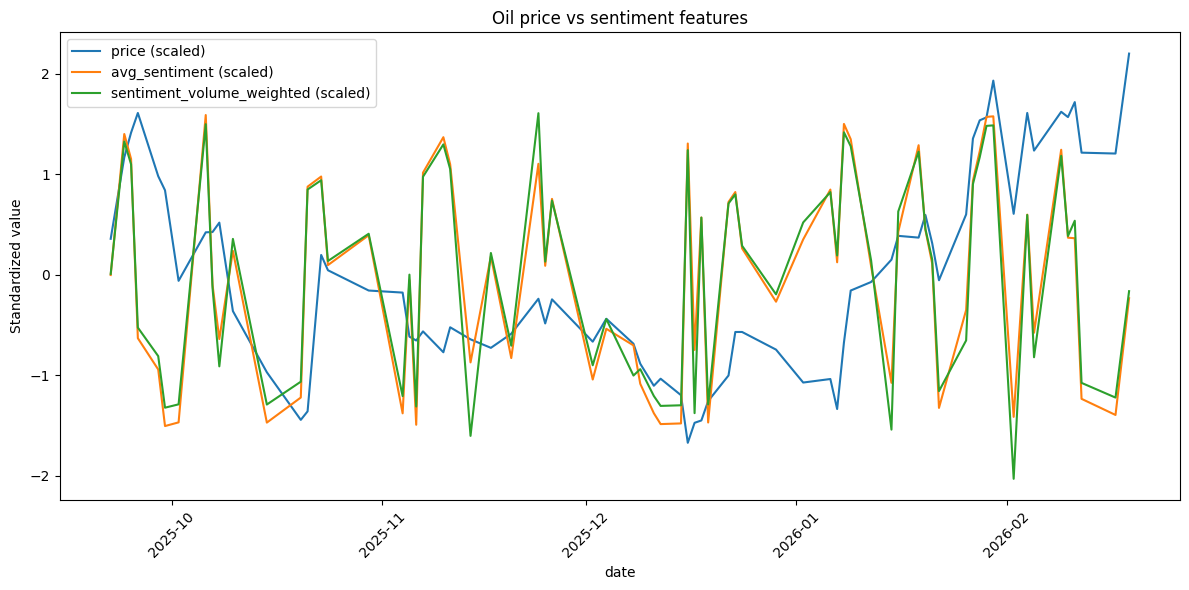

In [46]:

plot_scaled_overlay(
    merged,
    x_col="date",
    y_cols=["price", "avg_sentiment", "sentiment_volume_weighted"],
    title=f"{TARGET_TOPIC.title()} price vs sentiment features"
)


## 15. Plot lagged correlation

This checks whether sentiment becomes more useful when shifted by a few days.

That is important because markets may not react on the exact same day the news appears.


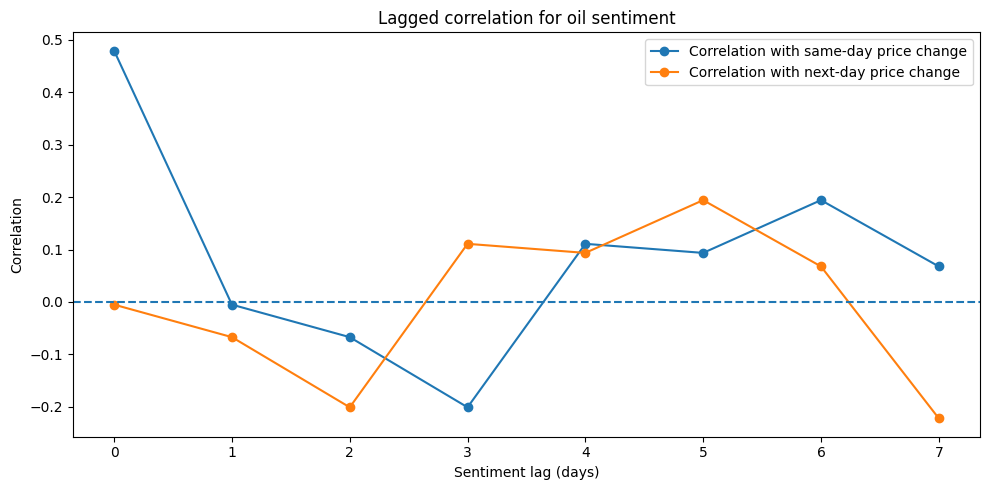

In [47]:

lags = range(0, 8)
lag_corrs_same_day_change = []
lag_corrs_next_day_change = []

for lag in lags:
    lagged_sent = merged["avg_sentiment"].shift(lag)
    lag_corrs_same_day_change.append(merged["price_change"].corr(lagged_sent))
    lag_corrs_next_day_change.append(merged["future_price_change"].corr(lagged_sent))

plt.figure(figsize=(10, 5))
plt.plot(list(lags), lag_corrs_same_day_change, marker="o", label="Correlation with same-day price change")
plt.plot(list(lags), lag_corrs_next_day_change, marker="o", label="Correlation with next-day price change")
plt.axhline(0, linestyle="--")
plt.xlabel("Sentiment lag (days)")
plt.ylabel("Correlation")
plt.title(f"Lagged correlation for {TARGET_TOPIC} sentiment")
plt.legend()
plt.tight_layout()
plt.show()


## 16. Results Summary

- Sentiment and oil price show a clear relationship, but sentiment is much more volatile.
- There is a strong same-day correlation, meaning prices react quickly to news.
- Some delayed effects appear around 4–6 days, suggesting slower market reactions as well.
- Short-term negative correlations (lag 2–3) may indicate price corrections after strong sentiment.
- Higher news volume tends to amplify sentiment impact.

**Overall:** News sentiment is useful, but noisy — it works best when combined with lag features rather than used directly.

## 17. Interpretation notes

Some practical interpretation guidance:

- A weak correlation with raw `price` is common.
- Sentiment is often more informative for `price_change` or `future_price_change` than for the price level itself.
- `news_volume` can matter because intense coverage often signals stronger market attention.
- If lagged sentiment performs better than same-day sentiment, that suggests delayed market reaction or imperfect alignment between publication time and trading data.

This notebook is  structured so it can be extended with:
- a regression model
- a classification model for up/down price movement
- rolling correlation analysis
- topic-specific comparison across oil, gas, and gold
